# Problem 1

Assume a given disease follows and SIR model, but we have developed a vaccine allowing us to reduce the size of $S$ to $S_{eff} \lt 1$.

## Part 1

Prove that if $R_0 \lt 1$ there can never be an outbreak.

Given from lecture:
$$
\mathit{R_0} = \frac{\beta}{\gamma}\\
\frac{dI}{dt} = \beta S I - \gamma I
$$

The main idea is that if $R_0 < 1$ that means people are recovering faster than people are being infected.

We can know that the infection rate is smaller than the recovery rate from the following.
$$
\mathit{R_0} \lt 1\\
\frac{\beta}{\gamma} \lt 1\\
\beta \lt \gamma
$$

To show that this doesn't lead to an outbreak we can first start with the full population $N$ in the susceptible $S$ bucket for initial growth rate. We need at least one infected so the below is only $S \approx N$.
$$
\frac{dI}{dt}= \beta N (1) - \gamma (1) \\
\frac{dI}{dt}= \beta N - \gamma
$$

Then, if we keep in line with the normalized equations we used during lecture, this would give us the following as our general growth rate. We then constrain this as less than 0 because we know the following about growth rate(<0 is decrease, =0 is equilibrium, >0 is outbreak).
$$
\beta - \gamma \lt 0
$$

All we need from here is to manipulate the symbols a bit to prove the original inequality.
$$
\beta - \gamma \lt 0\\
\frac{1}{\gamma}(\beta - \gamma \lt 0)\\
\frac{\beta}{\gamma} - 1 \lt 0\\
\mathit{R_0} - 1 \lt 0\\
\mathit{R_0} \lt 1
$$

## Part 2

What fraction of the population must be vaccinated in terms of $R_0$ (i.e. how much must we reduce $S_{eff}$) in order to prevent the disease from causing an outbreak?

Following the idea from Part (1), we know that outbreak is $\mathit{R_0} \gt 1$, so we want to at least reach equilibrium $\mathit{R_0} = 1$ to prevent the outbreak.

Where we previously normalized the equation, we want to bring population $N$ back to determine how many people to vaccinate.
$$
S \approx N\\
N = (1-v),\ where\ v\ is\ vaccinated
$$
This would then give us
$$
\mathit{R_0}N = 1\\
\mathit{R_0}(1-v) = 1
$$
From here we just isolate $v$ to get the proportion of the population to be vaccinated in terms of $\mathit{R_0}$.
$$
\mathit{R_0}(1-v) = 1\\
(1-v) = \frac{1}{\mathit{R_0}}\\
v = 1-\frac{1}{\mathit{R_0}}
$$
This would give the proportion of the population to vaccinate just to prevent an outbreak (equilibrium). You would need to switch to inequality to actually squash the disease.

## Part 3

What fraction of the population must be vaccinated in terms of $R_0=1.5,3,5,\ and\ 10$?

For $R_0 = 1.5$
$$
v = 1-\frac{1}{1.5} = \overline{.33}
$$
For $R_0 = 3$
$$
v = 1-\frac{1}{3} = \overline{.66}
$$
For $R_0 = 5$
$$
v = 1-\frac{1}{5} = .8
$$
For $R_0 = 10$
$$
v = 1-\frac{1}{10} = .9
$$

# Problem 2

Download the global $CO_2$ data from https://datahub-next-new.vercel.app/core/co2-ppm//_r/-/data/co2-mm-mlo.csv and temperature data from https://datahub.io/core/global-temp//_r/-/data/monthly.csv and take both the first and 12th difference.

### Data Prep

In [69]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf, plot_accf_grid
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.statespace.varmax import VARMAX

In [39]:
# Download the CSV files
co2_url = "https://datahub-next-new.vercel.app/core/co2-ppm/_r/-/data/co2-mm-mlo.csv"
temp_url = "https://datahub.io/core/global-temp/_r/-/data/monthly.csv"
co2_data = pd.read_csv(co2_url)
temp_data = pd.read_csv(temp_url)

# Sanity check
print(co2_data.head())
print(temp_data.head())

# Print types of each column
print(co2_data.dtypes)
print(temp_data.dtypes)

# Cast temp_data Year column as datetime datatype (Year-month)
# temp_data['Year'] = pd.to_datetime(temp_data['Year'], format='%Y-%m')

# Set temp_data Year column as index
temp_data = temp_data.set_index('Year')

              Date  Decimal Date  Average  Interpolated  Trend  Number of Days
1958-03  1958.2027        315.71   314.44            -1  -9.99           -0.99
1958-04  1958.2877        317.45   315.16            -1  -9.99           -0.99
1958-05  1958.3699        317.51   314.69            -1  -9.99           -0.99
1958-06  1958.4548        317.27   315.15            -1  -9.99           -0.99
1958-07  1958.5370        315.87   315.20            -1  -9.99           -0.99
  Source     Year    Mean
0   gcag  1850-01 -0.6746
1   gcag  1850-02 -0.3334
2   gcag  1850-03 -0.5913
3   gcag  1850-04 -0.5887
4   gcag  1850-05 -0.5088
Date              float64
Decimal Date      float64
Average           float64
Interpolated        int64
Trend             float64
Number of Days    float64
dtype: object
Source     object
Year       object
Mean      float64
dtype: object


In [40]:
# Plot each dataframes
fig = go.Figure()
fig.add_trace(go.Scatter(x=co2_data.index, y=co2_data['Average']))
fig.show()

In [41]:
# Plot temp_data
fig = go.Figure()
fig.add_trace(go.Scatter(x=temp_data.index, y=temp_data['Mean']))
fig.show()

### Differencing

In [46]:
# Take the first difference of both dataframes
co2_data['First Diff'] = co2_data['Average'].diff(periods=1)
temp_data['First Diff'] = temp_data['Mean'].diff(periods=1)

# Plot both dataframes
fig = go.Figure()
fig.add_trace(go.Scatter(x=co2_data.index, y=co2_data['First Diff']))
fig.add_trace(go.Scatter(x=temp_data.index, y=temp_data['First Diff']))
fig.show()

In [47]:
# Take the 12th difference of both dataframes
co2_data['12th Diff'] = co2_data['Average'].diff(periods=12)
temp_data['12th Diff'] = temp_data['Mean'].diff(periods=12)

# Plot both dataframes
fig = go.Figure()
fig.add_trace(go.Scatter(x=co2_data.index, y=co2_data['12th Diff']))
fig.add_trace(go.Scatter(x=temp_data.index, y=temp_data['12th Diff']))
fig.show()

In [48]:
# Combined difference
co2_data['Combined Diff'] = co2_data['12th Diff'].diff(periods=1)
temp_data['Combined Diff'] = temp_data['12th Diff'].diff(periods=1)

# Plot dataframes
fig = go.Figure()
fig.add_trace(go.Scatter(x=co2_data.index, y=co2_data['Combined Diff']))
fig.add_trace(go.Scatter(x=temp_data.index, y=temp_data['Combined Diff']))
fig.show()

## Part 1

Use the ADF to determine if the original time series and differenced series are stationsary.

In [54]:
# Make a quick function to format ADF test output
def print_adf(adf_test):
    print(f'ADF Statistic: {adf_test[0]:.4f}')
    print(f'p-value: {adf_test[1]:.4f}')
    print(f'Number of Lags: {adf_test[2]}')
    print(f'Number of Observations: {adf_test[3]}')
    print('Critical Values:')
    for key, value in adf_test[4].items():
        print(f'  {key}: {value:.4f}')

In [55]:
# Original Time Series
co2_adf = adfuller(co2_data['Average'].dropna())
temp_adf = adfuller(temp_data['Mean'].dropna())

print('CO2 Data ADF Test:')
print_adf(co2_adf)
print('\n')
print('Temperature Data ADF Test:')
print_adf(temp_adf)

CO2 Data ADF Test:
ADF Statistic: -5.0916
p-value: 0.0000
Number of Lags: 14
Number of Observations: 796
Critical Values:
  1%: -3.4386
  5%: -2.8652
  10%: -2.5687


Temperature Data ADF Test:
ADF Statistic: -1.1381
p-value: 0.6996
Number of Lags: 30
Number of Observations: 3792
Critical Values:
  1%: -3.4321
  5%: -2.8623
  10%: -2.5672


This shows that the CO2 time series rejects the null hypothesis meaning that it is likely stationary.

The Temperature time series fails to reject the null hypothesis meaning that it is likely non-stationary.

In [56]:
# First difference series
co2_adf = adfuller(co2_data['First Diff'].dropna())
temp_adf = adfuller(temp_data['First Diff'].dropna())

print('CO2 Data ADF Test:')
print_adf(co2_adf)
print('\n')
print('Temperature Data ADF Test:')
print_adf(temp_adf)

CO2 Data ADF Test:
ADF Statistic: -10.6917
p-value: 0.0000
Number of Lags: 20
Number of Observations: 789
Critical Values:
  1%: -3.4387
  5%: -2.8652
  10%: -2.5687


Temperature Data ADF Test:
ADF Statistic: -14.2012
p-value: 0.0000
Number of Lags: 30
Number of Observations: 3791
Critical Values:
  1%: -3.4321
  5%: -2.8623
  10%: -2.5672


Both time series reject the null hypothesis and are likely stationary. The ADF statistic is much higher than the original time series meaning we can reject the null more strongly.

In [57]:
# 12th difference series
co2_adf = adfuller(co2_data['12th Diff'].dropna())
temp_adf = adfuller(temp_data['12th Diff'].dropna())

print('CO2 Data ADF Test:')
print_adf(co2_adf)
print('\n')
print('Temperature Data ADF Test:')
print_adf(temp_adf)

CO2 Data ADF Test:
ADF Statistic: -11.4554
p-value: 0.0000
Number of Lags: 12
Number of Observations: 786
Critical Values:
  1%: -3.4387
  5%: -2.8652
  10%: -2.5687


Temperature Data ADF Test:
ADF Statistic: -13.3842
p-value: 0.0000
Number of Lags: 29
Number of Observations: 3781
Critical Values:
  1%: -3.4321
  5%: -2.8623
  10%: -2.5672


Both time series reject the null hypothesis and are likely stationary. The ADF statistics are also larger than the original time series, but shows that CO2 time series is maybe more strongly stationary and Temperature time series is less stationary than First differenced time series.

In [58]:
# Combined Difference
co2_adf = adfuller(co2_data['Combined Diff'].dropna())
temp_adf = adfuller(temp_data['Combined Diff'].dropna())

print('CO2 Data ADF Test:')
print_adf(co2_adf)
print('\n')
print('Temperature Data ADF Test:')
print_adf(temp_adf)

CO2 Data ADF Test:
ADF Statistic: -12.7401
p-value: 0.0000
Number of Lags: 21
Number of Observations: 776
Critical Values:
  1%: -3.4388
  5%: -2.8653
  10%: -2.5688


Temperature Data ADF Test:
ADF Statistic: -18.1090
p-value: 0.0000
Number of Lags: 29
Number of Observations: 3780
Critical Values:
  1%: -3.4321
  5%: -2.8623
  10%: -2.5672


This is the most strongly stationary of all the time series as it has the highest ADF statistic compared to the previous tests. This combined difference is the one where we can reject the null hypothesis most strongly.

## Part 2

Merge the two time series on any date they have in common, and then use `plot_accf_grid` on the differenced series. Remark on your findings.

In [60]:
# Merge dataframes on year+month
merged_data = pd.merge(co2_data, temp_data, left_index=True, right_index=True)

# Sanity Check
merged_data

,Date,Decimal Date,Average,Interpolated,Trend,Number of Days,First Diff_x,12th Diff_x,Combined Diff_x,Source,Mean,First Diff_y,12th Diff_y,Combined Diff_y
1958-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GISTEMP,0.0900,-0.0028,0.0000,-0.0199
1958-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gcag,0.0053,-0.0847,-0.0361,-0.0361
1958-04,0.0850,1.74,0.72,0.0,0.00,0.00,NaN,NaN,NaN,GISTEMP,0.0100,0.0047,0.0000,0.0361
1958-04,0.0850,1.74,0.72,0.0,0.00,0.00,NaN,NaN,NaN,gcag,-0.0695,-0.0795,-0.0687,-0.0687
1958-05,0.0822,0.06,-0.47,0.0,0.00,0.00,-1.19,NaN,NaN,GISTEMP,0.0600,0.1295,-0.0200,0.0487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03,0.0833,0.83,0.30,0.0,-0.25,-0.11,-0.82,0.15,-0.75,gcag,1.2515,-0.0387,0.0615,-0.0787
2024-04,0.0834,1.13,0.09,0.0,0.00,0.00,-0.21,-1.18,-1.33,gcag,1.2053,-0.0462,0.0060,-0.0555
2024-05,0.0833,0.39,-0.36,7.0,-0.23,-0.13,-0.45,-0.32,0.86,gcag,1.0745,-0.1308,-0.4055,-0.4115
2024-06,0.0833,0.01,0.81,-9.0,-0.11,0.01,1.17,0.34,0.66,gcag,1.1154,0.0409,-0.2368,0.1687


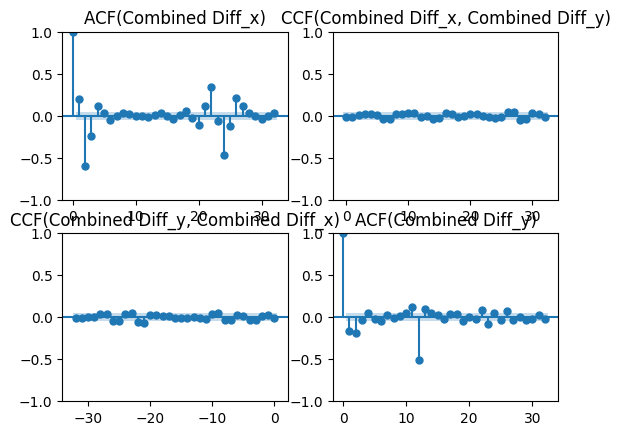

In [66]:
# Use plot_acf_grid
fig = plot_accf_grid(merged_data[['Combined Diff_x', 'Combined Diff_y']].dropna())
fig.show()

In the above graph, 'Combined Diff_x' and 'Combined Diff_y' is the differenced series of CO2 and Temperature respectively.

Just looking at the Cross-Correlation Function, we don't see much in the way of spikes outside the shaded bounds of the confidence intervals. As a result it means that there isn't a linear or lead-lag effect with a possibility of being independent.

## Part 3

Run Granger causality tests up to lag 18 in both directions and remark on the results.

In [67]:
grangercausalitytests(merged_data[['Combined Diff_x', 'Combined Diff_y']].dropna(), maxlag=18)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2982  , p=0.5851  , df_denom=1555, df_num=1
ssr based chi2 test:   chi2=0.2988  , p=0.5847  , df=1
likelihood ratio test: chi2=0.2987  , p=0.5847  , df=1
parameter F test:         F=0.2982  , p=0.5851  , df_denom=1555, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0998  , p=0.9050  , df_denom=1552, df_num=2
ssr based chi2 test:   chi2=0.2002  , p=0.9047  , df=2
likelihood ratio test: chi2=0.2002  , p=0.9048  , df=2
parameter F test:         F=0.0998  , p=0.9050  , df_denom=1552, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1867  , p=0.9055  , df_denom=1549, df_num=3
ssr based chi2 test:   chi2=0.5626  , p=0.9049  , df=3
likelihood ratio test: chi2=0.5625  , p=0.9050  , df=3
parameter F test:         F=0.1867  , p=0.9055  , df_denom=1549, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.9535  , p=0.

{np.int64(1): ({'ssr_ftest': (np.float64(0.2981800703465948),
    np.float64(0.585103939281612),
    np.float64(1555.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.2987553373633407),
    np.float64(0.5846637665508031),
    np.int64(1)),
   'lrtest': (np.float64(0.2987266970089877),
    np.float64(0.5846817706019326),
    np.int64(1)),
   'params_ftest': (np.float64(0.29818007034632726),
    np.float64(0.5851039392818294),
    np.float64(1555.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.09978074430964887),
    np.float64(0.9050416359335897),
    np.float64(1552.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.20020440578624132),
    np.float64(0.9047449457595801),
    np.int64(2)),
   'lrtest': (np.float64(0.20019153540442858),
    np.float64(0.9047507679847612),
    np.int64(2)),
   'params_ftest': (np.float64(0.09978074430938018),
    np.float64(0.9050416359339016),
    np.float64(1552.0),
    2.0)},
   array([[0., 0., 1., 0., 0.]

In the direction of CO2 -> Temperature, we can see that by lag 13 we pass the threshold of $\alpha = 0.05$ and it continues to get stronger the more lags we go. This indicates a strong likelihood that CO2 predicts Temperature.

In [68]:
grangercausalitytests(merged_data[['Combined Diff_y', 'Combined Diff_x']].dropna(), maxlag=18)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.7150  , p=0.3979  , df_denom=1555, df_num=1
ssr based chi2 test:   chi2=0.7163  , p=0.3973  , df=1
likelihood ratio test: chi2=0.7162  , p=0.3974  , df=1
parameter F test:         F=0.7150  , p=0.3979  , df_denom=1555, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4458  , p=0.6404  , df_denom=1552, df_num=2
ssr based chi2 test:   chi2=0.8944  , p=0.6394  , df=2
likelihood ratio test: chi2=0.8942  , p=0.6395  , df=2
parameter F test:         F=0.4458  , p=0.6404  , df_denom=1552, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4725  , p=0.7015  , df_denom=1549, df_num=3
ssr based chi2 test:   chi2=1.4239  , p=0.6999  , df=3
likelihood ratio test: chi2=1.4233  , p=0.7001  , df=3
parameter F test:         F=0.4725  , p=0.7015  , df_denom=1549, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.5330  , p=0.

{np.int64(1): ({'ssr_ftest': (np.float64(0.7149585208424861),
    np.float64(0.39793268758209155),
    np.float64(1555.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.7163378620402531),
    np.float64(0.3973477903754139),
    np.int64(1)),
   'lrtest': (np.float64(0.7161732334452608),
    np.float64(0.3974020339652453),
    np.int64(1)),
   'params_ftest': (np.float64(0.7149585208426603),
    np.float64(0.3979326875820345),
    np.float64(1555.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.4457858301668994),
    np.float64(0.640402858200754),
    np.float64(1552.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.8944439917137402),
    np.float64(0.6394019479347641),
    np.int64(2)),
   'lrtest': (np.float64(0.8941871761089715),
    np.float64(0.6394840574053742),
    np.int64(2)),
   'params_ftest': (np.float64(0.4457858301671237),
    np.float64(0.6404028582006434),
    np.float64(1552.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
  

In the direction of Temperature -> CO2, we can see that at lag 15 it drops below $\alpha=0.05$ but is not stable like the previous granger causality test. At lags 16, 17, and 18 we see the p-value escape the threshold to reject the null hypothesis.

As a result, it is not likely that Temperature is a predictor of CO2.

## Part 4

Fit a VAR(1) model and remark on whether the results agree with your findings in 2.3.

In [70]:
var1 = VARMAX(endog=merged_data[['Combined Diff_x', 'Combined Diff_y']].dropna(), order=(1,0), trend="c").fit(disp=True)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



In [71]:
var1.summary()

Dep. Variable:,"['Combined Diff_x', 'Combined Diff_y']",No. Observations:,1559
Model:,VAR(1),Log Likelihood,-611.924
,+ intercept,AIC,1241.848
Date:,"Thu, 04 Dec 2025",BIC,1290.014
Time:,18:18:25,HQIC,1259.757
Sample:,0,,
,- 1559,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"27.66, 2.15",Jarque-Bera (JB):,"10.19, 239.21"
Prob(Q):,"0.00, 0.14",Prob(JB):,"0.01, 0.00"
Heteroskedasticity (H):,"1.26, 0.98",Skew:,"0.04, -0.02"


When using a VAR(1) model we can look at the "L1.Combined Diff_y" p-value of the "Combined Diff_x" equation which is 0.657 to see that there isn't a cross-lagged correlation.

Looking at the "L1.Combined Diff_x" p-value of the "Combined Diff_y" equation which is 0.495, we can see that this also doesn't have a cross-lagged correlation.

As a result, the VAR(1) model results does not agree with the results I got in Part (2.3).